04 · Paths, spanning trees and flows

Four questions for a weighted graph: cheapest route, cheapest set of edges
that keeps it connected, how much flows from source to sink, where the
bottleneck is. `find_shortest_path`, `compute_mst`, `compute_max_flow`,
`compute_min_cut`, `animate_traversal` and `animate_flow` live in
`SciGraphs/core/algorithms/` (`pathfinding.py`, `spanning.py`,
`network_flow.py`) as thin NetworkX wrappers that read an edge weight **if the
graph carries one**, which on a graph built by the add-on is never. Every
operator is silently unweighted; sections 2, 3 and 4 check each against
NetworkX in the same cell.

The graphs are abstract and seeded: a weighted lattice, and a hand-built flow
network of twelve arcs, small enough that a shortest path is checkable by eye
and a min cut of four arcs is countable. Real graphs are notebook 01's
subject, layouts 16's, centrality and communities 17's, topological
invariants 19's.

No internet needed.

## 0 · Setup

In [1]:
import pathlib
import sys


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

import bpy
import geopandas as gpd
import networkx as nx
import numpy as np
import pandas as pd

from shapely.geometry import LineString, Point

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

from SciGraphs import api as sg

SEED = 18
rng = np.random.default_rng(SEED)

print("networkx", nx.__version__)
print("seed", SEED)

networkx 3.6
seed 18


### Abstract graphs on a georeferenced pipeline

`sg.graphs.from_gdf()` wants a nodes GeoDataFrame and an edges GeoDataFrame
with a `(source, target)` MultiIndex (city2graph's convention), projected
through an anchor. There is no abstract entry point, so an abstract graph
arrives dressed as a geographic one: positions in a metric CRS, the anchor
turning meters into Blender units, CRS and origin canceling out. 200 m
spacing at `scale=0.001` gives 0.2 Blender units between neighbors, the order
the geospatial notebooks work at, so `sg.render`'s size heuristics land where
they were calibrated.

In [2]:
CRS = "EPSG:32630"          # UTM 30N; arbitrary, and it cancels
ORIGIN = (500000.0, 4600000.0)
SPACING = 200.0             # meters between adjacent lattice nodes


def to_gdfs(graph, coords, edge_attrs=(), node_attrs=None):
    """A NetworkX graph as the (nodes, edges) pair `graph_to_blender` wants.

    `coords` maps node -> (column, row) in lattice units; `edge_attrs` names the
    edge data keys to carry across, `node_attrs` is a dict of name -> {node:
                                                                       value}. Numeric columns become mesh attributes, prefixed by `geo_mesh`: a
    node column `depth` lands as `node_depth`, an edge column `weight` as
    `edge_weight`. That prefix is not cosmetic; see section 1.
    """
    def point(n):
        return (ORIGIN[0] + coords[n][0] * SPACING,
                ORIGIN[1] + coords[n][1] * SPACING)

    columns = {} if node_attrs is None else {
        key: [float(values[n]) for n in graph.nodes()]
        for key, values in node_attrs.items()}
    nodes = gpd.GeoDataFrame(
        columns, geometry=[Point(point(n)) for n in graph.nodes()],
        index=pd.Index(list(graph.nodes()), name="node"), crs=CRS)

    rows = []
    for u, v, data in graph.edges(data=True):
        row = {"source": u, "target": v,
               "geometry": LineString([point(u), point(v)])}
        for key in edge_attrs:
            row[key] = float(data.get(key, 0.0))
        rows.append(row)
    edges = gpd.GeoDataFrame(rows, crs=CRS).set_index(["source", "target"])
    return nodes, edges

## 1 · The test bed: a weighted lattice

A 6×6 four-neighbor lattice, weights drawn once from U(1, 9). Small enough to
check every claim against the picture, regular enough that a route deviating
from the straight line does so for a visible reason.

In [3]:
SIDE = 6
G = nx.grid_2d_graph(SIDE, SIDE)
G = nx.convert_node_labels_to_integers(G, ordering="sorted",
                                       label_attribute="cell")
for u, v in G.edges():
    G[u][v]["weight"] = float(np.round(rng.uniform(1.0, 9.0), 2))

CELL = {n: c for n, c in G.nodes(data="cell")}

print(f"nodes {G.number_of_nodes()}  edges {G.number_of_edges()}")
weights = np.array([d["weight"] for _, _, d in G.edges(data=True)])
print(f"weights  min {weights.min():.2f}  median {np.median(weights):.2f}  "
      f"max {weights.max():.2f}")

check("the lattice is connected", nx.is_connected(G))
check("every edge carries a weight",
      all("weight" in d for _, _, d in G.edges(data=True)))

nodes 36  edges 60
weights  min 1.06  median 5.41  max 8.76
[PASS] the lattice is connected
[PASS] every edge carries a weight


True

### Into Blender

In [4]:
sg.graphs.clear_scene(keep_anchor=False)

nodes_g, edges_g = to_gdfs(G, CELL, edge_attrs=("weight",))
ANCHOR = sg.graphs.anchor_from(nodes_g, scale=0.001, name="Anchor_Algo")

obj_grid = sg.graphs.from_gdf(nodes_g, edges_g, name="Lattice", ref=ANCHOR,
                              coll="Algo",
                              markers={"graph_type": "grid_2d_graph",
                              "seed": SEED})

print(sg.graphs.summary(obj_grid))
print("\nattributes:")
for name, domain, dtype in sg.graphs.attributes(obj_grid):
    print(f"  {name:<28} {domain:<7} {dtype}")

{'object': 'Lattice', 'type': 'MESH', 'num_nodes': 36, 'num_edges': 60, 'is_directed': False, 'vertices': 36, 'mesh_edges': 60, 'attributes': ['position', '.edge_verts', '.corner_vert', '.corner_edge', 'node_id', 'edge_weight'], 'graph_type': 'grid_2d_graph'}

attributes:
  position                     POINT   FLOAT_VECTOR
  .edge_verts                  EDGE    INT32_2D
  .corner_vert                 CORNER  INT
  .corner_edge                 CORNER  INT
  node_id                      POINT   INT
  edge_weight                  EDGE    FLOAT


**The prefix.** `weight` in the GeoDataFrame is `edge_weight` on
the mesh (`geo_mesh.py:300`). Anything looking a weight up by its *source*
name finds nothing and falls back to a default; that already produced a GPU
edge backbone silently ranked by mesh order.

In [5]:
mesh = obj_grid.data
stored = np.zeros(len(mesh.edges), dtype=np.float64)
mesh.attributes["edge_weight"].data.foreach_get("value", stored)

pairs = np.empty(len(mesh.edges) * 2, dtype=np.int32)
mesh.edges.foreach_get("vertices", pairs)
pairs = pairs.reshape(-1, 2)
source_order = np.array([G[int(a)][int(b)]["weight"] for a, b in pairs])

check("the weight column arrives as edge_weight, not weight",
      "edge_weight" in mesh.attributes and "weight" not in mesh.attributes)
check("edge_weight is on the EDGE domain",
      sg.render.attribute_domain(obj_grid, "edge_weight") == "EDGE")
check("edge_weight is aligned with the mesh edge order",
      np.allclose(stored, source_order),
      f"max deviation {np.abs(stored - source_order).max():.3g}")

[PASS] the weight column arrives as edge_weight, not weight
[PASS] edge_weight is on the EDGE domain
[PASS] edge_weight is aligned with the mesh edge order — max deviation 3.43e-07


True

### A weight on the mesh is not safe there

**Applying a layout zeroes every EDGE-domain attribute.** Layout operators end
by calling `geometry.rebuild_edges(obj)`
(`ui/operators/scigraphs/layout_operators.py:322`, `:397`, `:483`, `:589`,
`:639`; also `data_operators.py:41`), which deletes every bmesh edge and
rebuilds it from the `edges_data` string (`core/mesh/geometry.py:1227-1248`).
Topology comes back identical, edge attributes at zero: same names, same
length, no values. Point attributes survive; the vertices are never rebuilt.

Nothing raises. A shortest path over all-zero weights is still a path, an MST
still a tree, a max flow over all-zero capacities 0. Only the last looks
wrong. The demonstration below runs on a throwaway copy.

In [6]:
scratch_nodes, scratch_edges = to_gdfs(G, CELL, edge_attrs=("weight",),
                                       node_attrs={"tag": {n: float(n)
                                       for n in G.nodes()}})
scratch = sg.graphs.from_gdf(scratch_nodes, scratch_edges, name="Scratch",
                             ref=ANCHOR, coll="Algo")


def edge_values(obj, attribute):
    """An EDGE-domain attribute as an array, or None when it is not there."""
    attr = obj.data.attributes.get(attribute)
    if attr is None or attr.domain != 'EDGE':
        return None
    values = np.zeros(len(obj.data.edges))
    attr.data.foreach_get("value", values)
    return values


def node_values(obj, attribute):
    """The POINT counterpart of `edge_values`."""
    attr = obj.data.attributes.get(attribute)
    if attr is None or attr.domain != 'POINT':
        return None
    values = np.zeros(len(obj.data.vertices))
    attr.data.foreach_get("value", values)
    return values


before_edges = edge_values(scratch, "edge_weight")
before_nodes = node_values(scratch, "node_tag")

sg.graphs.activate(scratch)
# `SPRING` reaches `nx.spring_layout` with no `seed=`
# (`core/mesh/layouts/networkx_layouts.py:8` and `:18`), so seeding NumPy's
# global generator immediately before the call is the only way to pin it.
np.random.seed(SEED)
print("apply_layout ->", bpy.ops.scigraphs.apply_layout(algorithm='SPRING',
      iterations=30,
      scale=5.0))

after_edges = edge_values(scratch, "edge_weight")
after_nodes = node_values(scratch, "node_tag")

print(f"\n  mesh edges          {len(before_edges)} → {len(after_edges)}")
print(f"  edge_weight range   {before_edges.min():.2f}-{before_edges.max():.2f}"
      f" → {after_edges.min():.2f}-{after_edges.max():.2f}")
print(f"  node_tag range      {before_nodes.min():.0f}-{before_nodes.max():.0f}"
      f" → {after_nodes.min():.0f}-{after_nodes.max():.0f}")

check("the layout kept the topology", len(after_edges) == len(before_edges))
check("the layout kept the point attribute",
      np.allclose(before_nodes, after_nodes))
check("the layout zeroed the edge attribute, silently",
      np.count_nonzero(after_edges) == 0,
      "the attribute is still on the mesh, and every value is 0.0")

sg.graphs.activate(scratch)
bpy.context.scene.scigraphs.pathfinding_source = "0"
bpy.context.scene.scigraphs.pathfinding_target = "35"
bpy.ops.scigraphs.find_shortest_path()
check("and the algorithms answer anyway",
      "shortest_path" in scratch.data.attributes,
      f"a path of {scratch['shortest_path_nodes']} nodes, distance "
      f"{scratch['shortest_path_length']:.2f}, over weights that are "
      "all zero")

bpy.data.objects.remove(scratch, do_unlink=True)


Layout algorithm: SPRING
Graph: 36 nodes, 60 edges
Parameters:
  - algorithm: SPRING
  - iterations: 30
  - scale: 5.0000
  - num_nodes: 36
  - num_edges: 60
Execution time: 0.002s
Status: success

Info: Layout 'SPRING' applied
apply_layout -> {'FINISHED'}

  mesh edges          60 → 60
  edge_weight range   1.06-8.76 → 0.00-0.00
  node_tag range      0-35 → 0-35
[PASS] the layout kept the topology
[PASS] the layout kept the point attribute
[PASS] the layout zeroed the edge attribute, silently — the attribute is still on the mesh, and every value is 0.0
Info: Path found: 11 nodes, distance: 10.00
[PASS] and the algorithms answer anyway — a path of 11 nodes, distance 10.00, over weights that are all zero


The rule, here and for anything computing on edge values: **lay
the graph out first, or not at all, and write the edge attributes last.**
Every graph here has its positions decided by construction, so no layout
operator touches an object that survives this cell. `weights_intact()` checks
that before each of the four algorithms. None of the operators reads these
values, but the mesh is the record a later reader will trust.

In [7]:
def weights_intact(obj, attribute, reference, label):
    """Assert an edge attribute still holds the values it was built with."""
    values = edge_values(obj, attribute)
    if values is None:
        return check(f"{label}: {attribute} survives", False, "gone")
    return check(f"{label}: {attribute} survives",
                 len(values) == len(reference)
                 and np.allclose(values, reference)
                 and np.count_nonzero(values) == len(values),
                 f"{len(values)} values, "
                 f"{values.min():.2f}-{values.max():.2f}, none zero")


weights_intact(obj_grid, "edge_weight", stored, "test bed")

[PASS] test bed: edge_weight survives — 60 values, 1.06-8.76, none zero


True

### The first figure, and what it is really showing

**The house style, once.** Every figure is EEVEE through
`nb.figure()`, top-down orthographic (a map read at an angle
cannot be measured off the page), `look='ink'`, the blackest of the five
looks, with turbo, whose low stop is a dark blue rather than a black that
would swallow a thin tube. Color always from an attribute computed here, node
size always from the graph. Here the attribute is `edge_weight`, and the
figure exposes something everything after it works around.

  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_weight  ·  edge_weight -> turbo [log]  [1.06 … 8.76] on Point


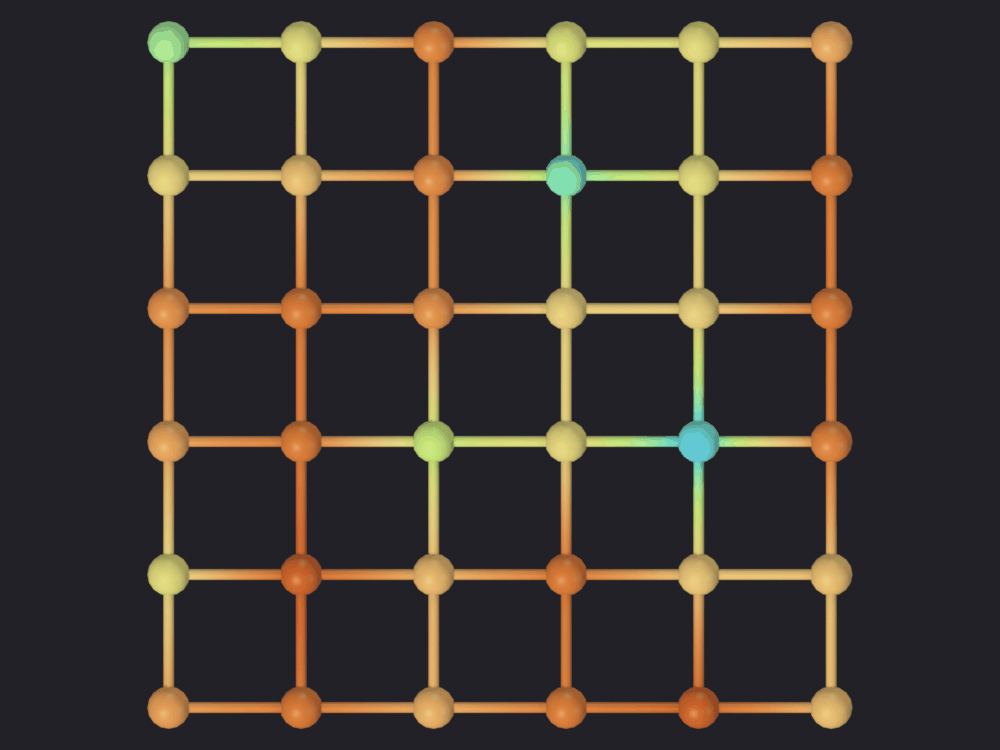

[PASS] 1_lattice.png legible — 15.9% ink (healthy range 0.5–60%)


In [8]:
NODE_FRACTION = 0.16   # see the Rendering section: 0.35 buries this lattice

nb.figure(obj_grid, "renders/04_algorithms/1_lattice",
          look='ink', color_attribute="edge_weight",
          node_fraction=NODE_FRACTION)

Each tube is a **gradient**, not one color: no edge is drawn in
the color of its own weight. A Blender color attribute may only live on
`POINT` or `CORNER` (`core/coloring/attributes.py:144`), and `CORNER` needs
faces, which a graph mesh has none of, so an `EDGE`-domain attribute is
written to `POINT` by averaging the incident edges at every vertex
(`core/coloring/attributes.py:227`). That averaging decides how a *subset* of
edges can be drawn at all, so it is worth measuring.

In [9]:
degree = np.zeros(len(mesh.vertices))
totals = np.zeros(len(mesh.vertices))
for (a, b), w in zip(pairs, stored):
    for v in (a, b):
        totals[v] += w
        degree[v] += 1
expected = totals / np.maximum(degree, 1)

layer = obj_grid.data.color_attributes[0]
print(f"color layer '{layer.name}'  domain {layer.domain}  "
      f"type {layer.data_type}")

check("the color layer is on POINT, not EDGE", layer.domain == "POINT")
check("one color per vertex, not one per edge",
      len(layer.data) == len(mesh.vertices),
      f"{len(layer.data)} colors, {len(mesh.vertices)} vertices, "
      f"{len(mesh.edges)} edges")

# A vertex whose mean matches none of its incident weights cannot be showing
# any edge's value, whatever the shader does with it later.
incident_weights = [stored[[i for i, (a, b) in enumerate(pairs) if v in (a, b)]]
                    for v in range(len(mesh.vertices))]
mismatched = [v for v, w in enumerate(incident_weights)
              if len(w) > 1 and not np.any(np.isclose(w, expected[v]))]
check("no vertex is showing an edge's own value",
      len(mismatched) == len(
      [w for w in incident_weights if len(w) > 1]),
      f"{len(mismatched)} of {len(mesh.vertices)} vertices")

print(f"\nper-vertex mean of incident edge_weight: "
      f"{expected.min():.2f} … {expected.max():.2f}")
print(f"per-edge edge_weight                  : "
      f"{stored.min():.2f} … {stored.max():.2f}")
print("the ramp is fitted to the second range and painted with the first")

color layer 'edge_weight_color'  domain POINT  type FLOAT_COLOR
[PASS] the color layer is on POINT, not EDGE
[PASS] one color per vertex, not one per edge — 36 colors, 36 vertices, 60 edges
[PASS] no vertex is showing an edge's own value — 36 of 36 vertices

per-vertex mean of incident edge_weight: 1.84 … 7.07
per-edge edge_weight                  : 1.06 … 8.76
the ramp is fitted to the second range and painted with the first


## 2 · Shortest paths

NetworkX on the same graph is the reference: once counting hops, once summing
`weight`.

In [10]:
SOURCE, TARGET = 0, 35   # opposite corners of the lattice

hop_path = nx.shortest_path(G, SOURCE, TARGET)
hop_len = nx.shortest_path_length(G, SOURCE, TARGET)
weighted_path = nx.shortest_path(G, SOURCE, TARGET, weight="weight")
weighted_len = nx.shortest_path_length(G, SOURCE, TARGET, weight="weight")


def cost_of(path):
    return sum(G[a][b]["weight"] for a, b in zip(path, path[1:]))


print(f"unweighted  {hop_len} hops   cost {cost_of(hop_path):6.2f}   {hop_path}")
print(f"weighted    {len(weighted_path) - 1} hops   "
      f"cost {weighted_len:6.2f}   {weighted_path}")

check("the two routes are not the same", hop_path != weighted_path)
check("the weighted route is cheaper by weight",
      weighted_len < cost_of(hop_path),
      f"{weighted_len:.2f} against {cost_of(hop_path):.2f}")
check("the unweighted route is not longer in hops",
      hop_len <= len(weighted_path) - 1)

unweighted  10 hops   cost  43.11   [0, 1, 2, 3, 4, 5, 11, 17, 23, 29, 35]
weighted    10 hops   cost  31.26   [0, 6, 12, 13, 14, 20, 21, 22, 28, 29, 35]
[PASS] the two routes are not the same
[PASS] the weighted route is cheaper by weight — 31.26 against 43.11
[PASS] the unweighted route is not longer in hops


True

Both routes take 10 hops, as every monotone staircase from one
corner to the other does. The weight decides *which* staircase, and the gap in
cost is the size of the mistake an unweighted answer makes.

### What the operator does

`bpy.ops.scigraphs.find_shortest_path()` reads `pathfinding_source`,
`pathfinding_target` and `pathfinding_algorithm`, and nothing else. There is
no field for a weight attribute anywhere in the property group
(`properties/splitter_properties.py:387-409`).

In [11]:
weights_intact(obj_grid, "edge_weight", stored, "before find_shortest_path")

sg.graphs.activate(obj_grid)
props = bpy.context.scene.scigraphs
props.pathfinding_source = str(SOURCE)
props.pathfinding_target = str(TARGET)
props.pathfinding_algorithm = 'DIJKSTRA'

result = bpy.ops.scigraphs.find_shortest_path()
print("find_shortest_path ->", result)
print(f"  nodes on the path : {obj_grid['shortest_path_nodes']}")
print(f"  reported distance : {obj_grid['shortest_path_length']}")

flag = np.zeros(len(mesh.vertices))
mesh.attributes["shortest_path"].data.foreach_get("value", flag)
operator_path = sorted(int(i) for i in np.flatnonzero(flag > 0.5))
print(f"  path (as a node set): {operator_path}")

check("the operator's distance is the hop count, not the weighted cost",
      abs(obj_grid["shortest_path_length"] - hop_len) < 1e-6
      and abs(obj_grid["shortest_path_length"] - weighted_len) > 1.0,
      f"{obj_grid['shortest_path_length']:.2f} = {hop_len} hops, "
      f"not {weighted_len:.2f}")

[PASS] before find_shortest_path: edge_weight survives — 60 values, 1.06-8.76, none zero
Info: Path found: 11 nodes, distance: 10.00
find_shortest_path -> {'FINISHED'}
  nodes on the path : 11
  reported distance : 10.0
  path (as a node set): [0, 6, 12, 13, 14, 15, 16, 17, 23, 29, 35]
[PASS] the operator's distance is the hop count, not the weighted cost — 10.00 = 10 hops, not 31.26


True

> **The weight is never read.** `parse_graph_data()` builds a
> `GraphData(nodes, edges, None)` (`core/mesh/mesh_utils.py:100`); `GraphData`
> has only `nodes`, `edges`, `dataframe` (`core/algorithms/graph.py:3`). Every
> algorithm guards its weight lookup with
> `hasattr(graph_data, 'edge_weights')` (`pathfinding.py:32`,
> `spanning.py:29`, `network_flow.py:31`), an attribute no object the add-on
> constructs has, so the guard is `False` everywhere and the weight is the
> literal `1.0`. The operator is breadth-first search wearing Dijkstra's name.

Strip `edge_weight` off the mesh entirely and run it again.

In [12]:
backup = stored.copy()
mesh.attributes.remove(mesh.attributes["edge_weight"])
print("edge_weight on the mesh:", "edge_weight" in mesh.attributes)

bpy.ops.scigraphs.find_shortest_path()
flag_without = np.zeros(len(mesh.vertices))
mesh.attributes["shortest_path"].data.foreach_get("value", flag_without)

check("removing the weight changes nothing",
      np.array_equal(flag, flag_without)
      and abs(obj_grid["shortest_path_length"] - hop_len) < 1e-6,
      "same path, same reported distance")

restored = mesh.attributes.new(name="edge_weight", type='FLOAT', domain='EDGE')
restored.data.foreach_set("value", backup.tolist())
print("edge_weight restored:", "edge_weight" in mesh.attributes)
weights_intact(obj_grid, "edge_weight", stored, "after the experiment")

edge_weight on the mesh: False
Info: Path found: 11 nodes, distance: 10.00
[PASS] removing the weight changes nothing — same path, same reported distance
edge_weight restored: True
[PASS] after the experiment: edge_weight survives — 60 values, 1.06-8.76, none zero


True

Two failure modes look identical from here: the weight is never
read (this one, and no state on the object would show it), or the weight is
read after a layout has wiped it to zero. `weights_intact()` catches the
second; nothing catches the first except comparing against a computation done
elsewhere.

`ASTAR` is the same: `a_star_path()` takes the node positions
for its heuristic and the same `1.0` for weights (`pathfinding.py:87`).
`BELLMAN_FORD` is in the enum but never dispatched; the operator tests for
`'ASTAR'` and sends the rest to Dijkstra
(`ui/operators/scigraphs/algorithms_operators.py:151`).

The route out, taken for all four algorithms: compute with NetworkX, write the
answer back as an attribute, and let the operators put it into the scene,
which they do faithfully.

In [13]:
props.pathfinding_algorithm = 'ASTAR'
bpy.ops.scigraphs.find_shortest_path()
print(f"A*        distance {obj_grid['shortest_path_length']:.2f}")
props.pathfinding_algorithm = 'BELLMAN_FORD'
bpy.ops.scigraphs.find_shortest_path()
print(f"Bellman-Ford (→ Dijkstra) distance "
      f"{obj_grid['shortest_path_length']:.2f}")
props.pathfinding_algorithm = 'DIJKSTRA'

check("all three menu entries report the same unweighted distance",
      abs(obj_grid["shortest_path_length"] - hop_len) < 1e-6)

Info: Path found: 11 nodes, distance: 10.00
A*        distance 10.00
Info: Path found: 11 nodes, distance: 10.00
Bellman-Ford (→ Dijkstra) distance 10.00
[PASS] all three menu entries report the same unweighted distance


True

### Drawing a path

A path is a **subset** of the edges, not a continuous attribute. The Rendering
section measures why color cannot carry membership here; geometry carries it
instead, and `overlay()` is that arrangement: a second graph object drawn
thicker over a context drawn darker, which leaves color for a magnitude.

In [14]:
CONTEXT = (0.085, 0.080, 0.100)   # measured in the Rendering section
FAT = 2.4                         # highlight tube radius, relative to context

LAYERS = [obj_grid]               # every graph object, for hide bookkeeping


def plain(obj):
    """Strip a previous coloring so a flat `color=` decides the object again.

    `sg.render.material()` never takes a material away and `geometry_nodes()`
    re-wires whichever color shader it finds, both so that a graph colored and
    then rendered keeps its colormap. The context object wants the opposite and
    has to ask for it.
    """
    layers = obj.data.color_attributes
    for name in [a.name for a in layers]:
        layers.remove(layers[name])
    for key in ("scigraphs_last_color_attribute", "scigraphs_color_attr"):
        if key in obj.keys():
            del obj[key]
    obj.data.materials.clear()
    return obj


def luminance(path):
    """(rgb, luminance) for a PNG, on the 0-255 scale it was written in."""
    from PIL import Image
    rgb = np.asarray(Image.open(str(path)).convert("RGB"), dtype=np.float32)
    return rgb, 0.2126 * rgb[..., 0] + 0.7152 * rgb[..., 1] + 0.0722 * rgb[..., 2]


def overlay(base, highlight, attribute, filename, extra=(),
            node_fraction=NODE_FRACTION, fat=FAT, measure=True,
            context_color=CONTEXT):
    """Draw `highlight` over `base`, and measure whether it reads.

    Returns the render's path and, when `measure`, the median luminance of the
    pixels the highlight reaches (found by rendering the same frame again with
                                  it hidden) against the median of the context's own ink.
    """
    sizes = sg.render.autoscale_geometry(base, node_fraction=node_fraction,
                                         verbose=False)
    for obj, ratio, color in [(highlight, fat, context_color), *extra]:
        sg.render.autoscale_geometry(obj, node_fraction=node_fraction,
                                     verbose=False)
        obj["scigraphs_node_size"] = sizes["node_radius"] * 1e-3
        obj["scigraphs_edge_thickness"] = sizes["edge_radius"] * ratio
        sg.render.material(obj, color=color)
        sg.render.geometry_nodes(obj)
    # `nodes_only` defaults True for a point attribute. These spheres were
    # just shrunk to nothing, so the colormap has to reach the tubes: measured
    # on the tree figure, 70 levels of separation against 16.
    sg.render.color_graph(highlight, attribute, colormap="turbo",
                          nodes_only=False, verbose=False)

    shown = {base, highlight, *(o for o, _, _ in extra)}
    hidden = [o for o in LAYERS if o not in shown]

    plain(base)
    # `shrink_png` picks its palette per image, so a pair compared pixel by
    # pixel stays unquantized until after the measurement.
    full = nb.render(
        base, filename, look='ink', isolate=False, color=context_color,
        node_fraction=node_fraction, hide=hidden, verbose=False,
        shrink=not measure)
    if not measure:
        plain(base)
        return full, None

    reference = nb.render(
        base, filename + "_context", look='ink', isolate=False,
        color=context_color,
        node_fraction=node_fraction, hide=hidden + [highlight], verbose=False,
        shrink=False)
    rgb_full, lum_full = luminance(full)
    rgb_ref, lum_ref = luminance(reference)
    reached = np.abs(lum_full - lum_ref) > 8
    ink_ref = np.abs(rgb_ref - rgb_ref.reshape(-1, 3)[0]).sum(axis=2) > 24
    numbers = {
        "highlight_median": float(np.median(lum_full[reached])),
        "highlight_p05": float(np.percentile(lum_full[reached], 5)),
        "highlight_area": float(reached.mean()),
        "context_median": float(np.median(lum_ref[ink_ref])),
    }
    numbers["separation"] = numbers["highlight_median"] - numbers["context_median"]
    plain(base)
    sg.preview.shrink_png(full)
    sg.preview.shrink_png(reference)
    return full, numbers

The highlight carries the **cumulative cost from the source** on
the node domain: 0 at the start, the total at the end. Being a point
attribute, it escapes section 1's averaging, and each tube interpolates two
genuinely adjacent costs. The unweighted route goes underneath in flat mid
gray: three tiers, lattice, hop route, weighted route.

Info: Geometry Nodes modifier added
Info: Geometry Nodes modifier added
Info: Attribute -> node_cost  ·  node_cost -> turbo [log]  [0 … 31.26] on Point
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added


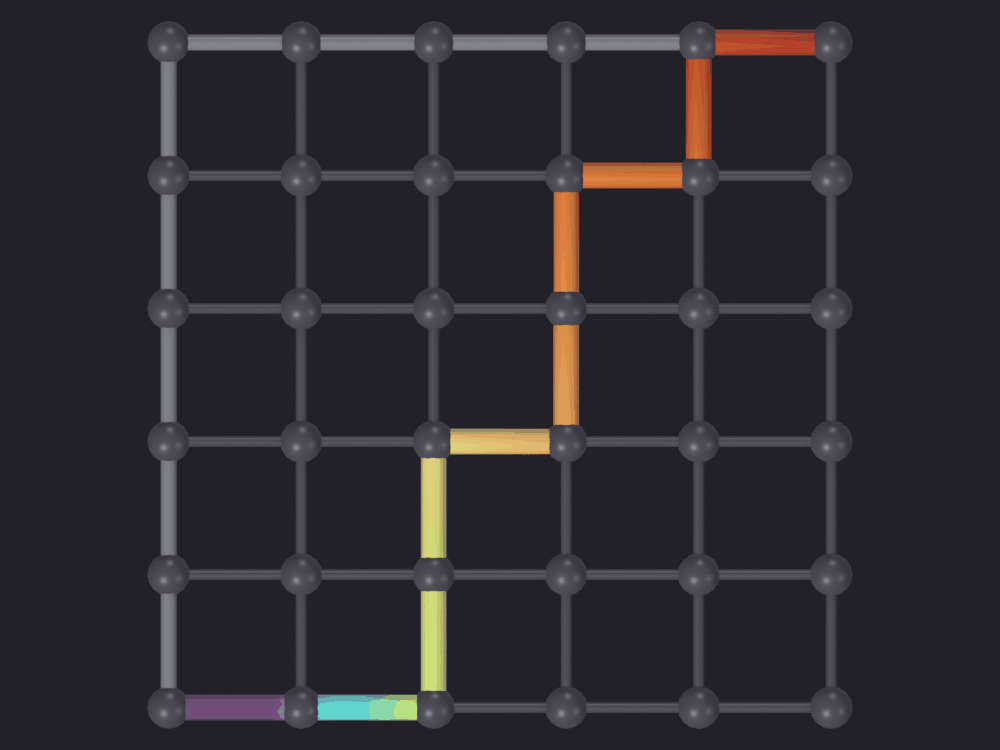

[PASS] 2_paths.png legible — 17.6% ink (healthy range 0.5–60%)
  weighted route : median luminance 136, dimmest 5% at 67
  lattice        : median luminance 75
  separation     : 61 gray levels


In [15]:
cumulative = {n: 0.0 for n in G.nodes()}
running = 0.0
for a, b in zip(weighted_path, weighted_path[1:]):
    running += G[a][b]["weight"]
    cumulative[b] = running

path_graph = nx.Graph()
path_graph.add_nodes_from(G.nodes())
path_graph.add_edges_from(zip(weighted_path, weighted_path[1:]))
nodes_p, edges_p = to_gdfs(path_graph, CELL, node_attrs={"cost": cumulative})
obj_path = sg.graphs.from_gdf(nodes_p, edges_p, name="Path_Weighted",
                              ref=ANCHOR, coll="Algo")

hops_graph = nx.Graph()
hops_graph.add_nodes_from(G.nodes())
hops_graph.add_edges_from(zip(hop_path, hop_path[1:]))
nodes_h, edges_h = to_gdfs(hops_graph, CELL)
obj_hops = sg.graphs.from_gdf(nodes_h, edges_h, name="Path_Hops",
                              ref=ANCHOR, coll="Algo")
LAYERS += [obj_path, obj_hops]

path, path_numbers = overlay(obj_grid, obj_path, "node_cost",
                             "renders/04_algorithms/2_paths",
                             extra=[(obj_hops, 1.5, (0.26, 0.26, 0.30))])
nb.show(path)
nb.check_render(path)
print(f"  weighted route : median luminance "
      f"{path_numbers['highlight_median']:.0f}, "
      f"dimmest 5% at {path_numbers['highlight_p05']:.0f}")
print(f"  lattice        : median luminance "
      f"{path_numbers['context_median']:.0f}")
print(f"  separation     : {path_numbers['separation']:.0f} gray levels")

## 3 · Minimum spanning trees

The cheapest set of edges that leaves the graph connected: 35 out of 60 on
this 36-node lattice, so the *missing* edges are what to look for.

The claim "this is a minimum spanning tree" has four parts and none implies
the others. Notebook 16 checks its proximity graphs the same way, by
containment rather than count.

In [16]:
tree = nx.minimum_spanning_tree(G, weight="weight")
tree_weight = sum(d["weight"] for _, _, d in tree.edges(data=True))

check("n − 1 edges",
      tree.number_of_edges() == G.number_of_nodes() - 1,
      f"{tree.number_of_edges()} for {G.number_of_nodes()} nodes")
check("acyclic", nx.is_forest(tree))
check("spanning: one component, every node in it",
      nx.is_connected(tree)
      and set(tree.nodes()) == set(G.nodes()))
check("a subgraph of the lattice, not a new graph",
      {tuple(sorted(e)) for e in tree.edges()}
      <= {tuple(sorted(e)) for e in G.edges()})

print(f"\nMST weight {tree_weight:.2f} "
      f"against {weights.sum():.2f} for the whole lattice")

[PASS] n − 1 edges — 35 for 36 nodes
[PASS] acyclic
[PASS] spanning: one component, every node in it
[PASS] a subgraph of the lattice, not a new graph

MST weight 119.10 against 297.73 for the whole lattice


Minimality is the one claim a structural check cannot make.
Sampling random spanning trees is enough to catch an implementation that
returns *a* tree instead of *the* tree, which is the failure mode below.

In [17]:
TRIALS = 200
sampled = []
for _ in range(TRIALS):
    perturbed = nx.Graph()
    perturbed.add_nodes_from(G.nodes())
    for u, v in G.edges():
        perturbed.add_edge(u, v, key=float(rng.random()))
    random_tree = nx.minimum_spanning_tree(perturbed, weight="key")
    sampled.append(sum(G[u][v]["weight"] for u, v in random_tree.edges()))

sampled = np.array(sampled)
check("no sampled spanning tree beats it",
      bool((sampled >= tree_weight - 1e-9).all()),
      f"{TRIALS} random spanning trees, cheapest {sampled.min():.2f}, "
      f"median {np.median(sampled):.2f}, against {tree_weight:.2f}")

[PASS] no sampled spanning tree beats it — 200 random spanning trees, cheapest 149.67, median 175.71, against 119.10


True

### What the operator does

In [18]:
weights_intact(obj_grid, "edge_weight", stored, "before compute_mst")

sg.graphs.activate(obj_grid)
props.spanning_algorithm = 'KRUSKAL'
print("compute_mst ->", bpy.ops.scigraphs.compute_mst())
print(f"  edges  {obj_grid['mst_edges']}")
print(f"  weight {obj_grid['mst_weight']}")

check("the operator finds the right number of edges",
      obj_grid["mst_edges"] == G.number_of_nodes() - 1)
check("its weight is the edge count, not the sum of the weights",
      abs(obj_grid["mst_weight"] - (G.number_of_nodes() - 1)) < 1e-6,
      f"{obj_grid['mst_weight']:.2f} = 35 × 1.0, not {tree_weight:.2f}")

kruskal_edges = {tuple(sorted(e)) for e in
                 nx.minimum_spanning_tree(
                 nx.Graph([(u, v, {"w": 1.0}) for u, v in G.edges()]),
                 algorithm="kruskal", weight="w").edges()}
kruskal_cost = sum(G[u][v]["weight"] for u, v in kruskal_edges)
print(f"the tree the operator actually returned costs {kruskal_cost:.2f}")
print(f"the minimum spanning tree costs             {tree_weight:.2f}")
print(f"the median of {TRIALS} random spanning trees    "
      f"{np.median(sampled):.2f}")

check("what the operator returned is a spanning tree",
      len(kruskal_edges) == G.number_of_nodes() - 1)
check("and it is not the minimum one",
      kruskal_cost > tree_weight + 1e-9,
      f"{kruskal_cost - tree_weight:.2f} more, "
      f"{(kruskal_cost / tree_weight - 1) * 100:.0f}% over")

[PASS] before compute_mst: edge_weight survives — 60 values, 1.06-8.76, none zero
Info: Kruskal: 35 edges, weight: 35.00
compute_mst -> {'FINISHED'}
  edges  35
  weight 35.0
[PASS] the operator finds the right number of edges
[PASS] its weight is the edge count, not the sum of the weights — 35.00 = 35 × 1.0, not 119.10
the tree the operator actually returned costs 174.36
the minimum spanning tree costs             119.10
the median of 200 random spanning trees    175.71
[PASS] what the operator returned is a spanning tree
[PASS] and it is not the minimum one — 55.26 more, 46% over


True

Same cause as section 2, different symptom. With every weight
equal to 1 every spanning tree is minimal, so Kruskal returns whichever it
reaches first: a valid tree at a real cost the operator never computes, priced
above outside Blender. Nothing in the add-on can tell you the gap is there.

> **The result does not reach the mesh either.** `spanning.py` builds an
> `edge_in_mst` array, one flag per edge in mesh order, exactly what a figure
> needs (`spanning.py:42-48`); `SCIGRAPHS_OT_ComputeMST.execute` keeps
> `num_edges` and `total_weight` and drops it
> (`ui/operators/scigraphs/algorithms_operators.py:210`).

In [19]:
print("attributes after compute_mst:")
print(" ", [a.name for a in mesh.attributes])
check("no per-edge MST attribute was written",
      not any(a.name.startswith("mst") or a.name == "edge_in_mst"
      for a in mesh.attributes))

attributes after compute_mst:
  ['position', '.edge_verts', '.corner_vert', '.corner_edge', 'node_id', 'shortest_path', 'edge_weight']
[PASS] no per-edge MST attribute was written


True

### The tree, drawn

The highlight carries **depth in the tree** from node 0, a point attribute
again: distance from the root along the tree's own edges, so the ramp reads
outward from the root rather than across the frame.

tree depth from node 0: 0 … 15
Info: Geometry Nodes modifier added
Info: Attribute -> node_depth  ·  node_depth -> turbo [log]  [0 … 15] on Point
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added


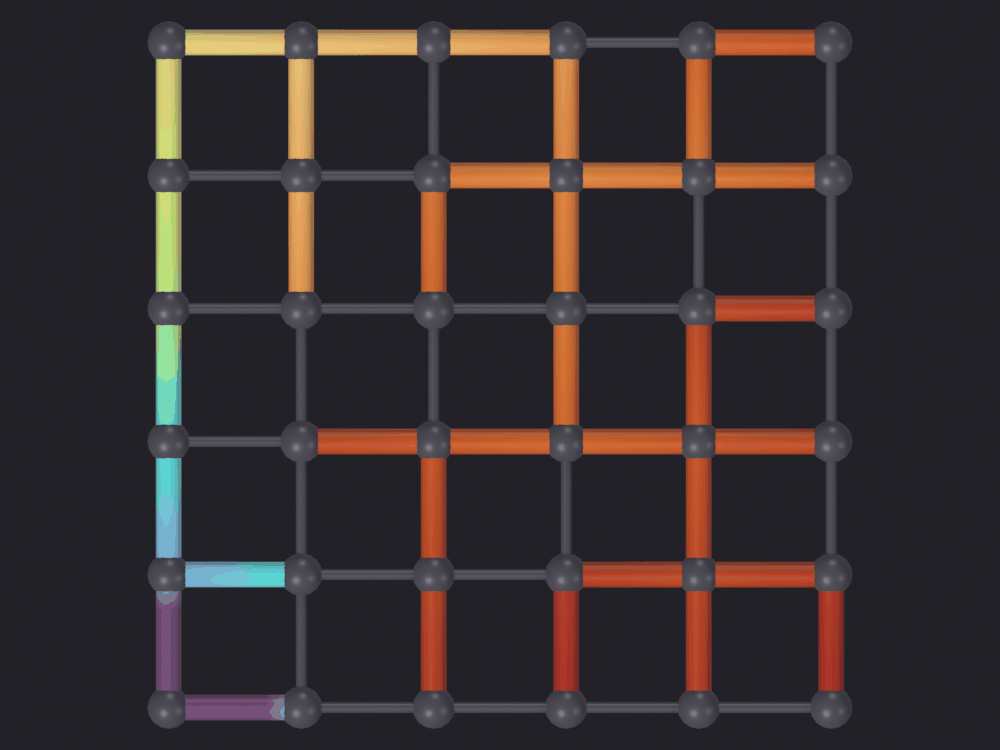

[PASS] 3_mst.png legible — 21.9% ink (healthy range 0.5–60%)
  tree    : median luminance 109, 12.3% of the frame
  lattice : median luminance 74
  separation: 35 gray levels


In [20]:
depth = nx.single_source_shortest_path_length(tree, SOURCE)

tree_graph = nx.Graph()
tree_graph.add_nodes_from(G.nodes())
tree_graph.add_edges_from(tree.edges())
nodes_t, edges_t = to_gdfs(tree_graph, CELL,
                           node_attrs={"depth": {n: float(depth[n])
                           for n in G.nodes()}})
obj_tree = sg.graphs.from_gdf(nodes_t, edges_t, name="MST", ref=ANCHOR,
                              coll="Algo")
LAYERS.append(obj_tree)

print(f"tree depth from node {SOURCE}: 0 … {max(depth.values())}")

path, mst_numbers = overlay(obj_grid, obj_tree, "node_depth",
                            "renders/04_algorithms/3_mst")
nb.show(path)
nb.check_render(path)
print(f"  tree    : median luminance {mst_numbers['highlight_median']:.0f}, "
      f"{mst_numbers['highlight_area'] * 100:.1f}% of the frame")
print(f"  lattice : median luminance {mst_numbers['context_median']:.0f}")
print(f"  separation: {mst_numbers['separation']:.0f} gray levels")

## 4 · Max-flow and min-cut

These two are one theorem: the maximum flow from a source to a sink equals the
total capacity of the cheapest set of arcs whose removal disconnects them. It
is the one claim that fails loudly when either half is wrong, so it is checked
numerically here.

A lattice would be a bad demonstration, its cuts uninteresting and its
capacities invented anyway. This is a hand-built network of eight nodes and
twelve arcs, laid out left to right in layers, with capacities chosen so the
min cut is **not** simply the arcs leaving the source or entering the sink. It
crosses two layers, which is what makes it worth drawing.

In [21]:
CAPACITY = {
    (0, 1): 20, (0, 2): 6, (0, 3): 8,
    (1, 4): 3, (1, 5): 2,
    (2, 4): 3, (2, 5): 5,
    (3, 5): 2, (3, 6): 7,
    (4, 7): 14, (5, 7): 12, (6, 7): 10,
}
LAYOUT = {0: (0.0, 1.5), 1: (1.4, 3.0), 2: (1.4, 1.5), 3: (1.4, 0.0),
          4: (2.8, 3.0), 5: (2.8, 1.5), 6: (2.8, 0.0), 7: (4.2, 1.5)}
SRC, SINK = 0, 7

F = nx.DiGraph()
for (u, v), c in CAPACITY.items():
    F.add_edge(u, v, capacity=float(c))

print(f"nodes {F.number_of_nodes()}  arcs {F.number_of_edges()}  "
      f"source {SRC} → sink {SINK}")
print(f"capacity leaving the source : "
      f"{sum(c for (u, _), c in CAPACITY.items() if u == SRC)}")
print(f"capacity entering the sink  : "
      f"{sum(c for (_, v), c in CAPACITY.items() if v == SINK)}")

nodes 8  arcs 12  source 0 → sink 7
capacity leaving the source : 34
capacity entering the sink  : 36


### The duality, checked

In [22]:
flow_value, flow_dict = nx.maximum_flow(F, SRC, SINK, capacity="capacity")
cut_value, (near, far) = nx.minimum_cut(F, SRC, SINK, capacity="capacity")
cut_edges = sorted((u, v) for u in near for v in far if F.has_edge(u, v))

for u, v in F.edges():
    F[u][v]["flow"] = float(flow_dict[u][v])

print(f"max flow  {flow_value:.0f}")
print(f"min cut   {cut_value:.0f}  over {len(cut_edges)} arcs {cut_edges}")
print(f"source side {sorted(near)}   sink side {sorted(far)}")

check("max flow = min cut", abs(flow_value - cut_value) < 1e-9,
      f"{flow_value:.0f} = {cut_value:.0f}")
check("the cut's capacity is that number",
      abs(sum(CAPACITY[e] for e in cut_edges) - cut_value) < 1e-9,
      " + ".join(str(CAPACITY[e]) for e in cut_edges)
      + f" = {cut_value:.0f}")
check("every cut arc is saturated",
      all(abs(F[u][v]["flow"] - CAPACITY[(u, v)]) < 1e-9
      for u, v in cut_edges))
check("flow is conserved at every intermediate node",
      all(abs(sum(flow_dict[w][x] for x in F.successors(w))
      - sum(flow_dict[x][w] for x in F.predecessors(w))) < 1e-9
      for w in F.nodes() if w not in (SRC, SINK)))
check("the cut crosses more than one layer",
      len({u for u, _ in cut_edges}) > 1,
      f"it leaves nodes {sorted({u for u, _ in cut_edges})}")

max flow  19
min cut   19  over 4 arcs [(0, 2), (0, 3), (1, 4), (1, 5)]
source side [0, 1]   sink side [2, 3, 4, 5, 6, 7]
[PASS] max flow = min cut — 19 = 19
[PASS] the cut's capacity is that number — 6 + 8 + 3 + 2 = 19
[PASS] every cut arc is saturated
[PASS] flow is conserved at every intermediate node
[PASS] the cut crosses more than one layer — it leaves nodes [0, 1]


True

### Into Blender, and the first thing the operators say

`graph_to_blender` hard-codes `is_directed = False` on everything it builds
(`core/mesh/geo_mesh.py:249`); the edges frame's directedness is never
consulted. Both flow operators refuse an undirected graph, so they reject a
directed graph imported this way.

In [23]:
nodes_f, edges_f = to_gdfs(F, LAYOUT, edge_attrs=("capacity", "flow"))
obj_flow = sg.graphs.from_gdf(nodes_f, edges_f, name="FlowNetwork",
                              ref=ANCHOR, coll="Algo",
                              markers={"graph_type": "flow_network"})
LAYERS.append(obj_flow)
print(sg.graphs.summary(obj_flow))

capacities = np.array([CAPACITY[(u, v)] for u, v in F.edges()])
weights_intact(obj_flow, "edge_capacity", capacities,
               "before compute_max_flow")

sg.graphs.activate(obj_flow)
props.flow_source = str(SRC)
props.flow_sink = str(SINK)
try:
    bpy.ops.scigraphs.compute_max_flow()
    refused = None
except RuntimeError as exc:
    refused = str(exc)
print("compute_max_flow on the graph as built:", refused)
check("a directed graph arrives marked undirected",
      obj_flow.get("is_directed") is False and refused is not None)

{'object': 'FlowNetwork', 'type': 'MESH', 'num_nodes': 8, 'num_edges': 12, 'is_directed': False, 'vertices': 8, 'mesh_edges': 12, 'attributes': ['position', '.edge_verts', '.corner_vert', '.corner_edge', 'node_id', 'edge_capacity', 'edge_flow'], 'graph_type': 'flow_network'}
[PASS] before compute_max_flow: edge_capacity survives — 12 values, 2.00-20.00, none zero
Error: Max flow requires directed graph
compute_max_flow on the graph as built: Error: Max flow requires directed graph

[PASS] a directed graph arrives marked undirected


True

The marker is a custom property, so the workaround is one line.
A workaround, not a fix: the arcs survived the import in the right order, only
the flag is wrong.

In [24]:
obj_flow["is_directed"] = True
print("compute_max_flow ->", bpy.ops.scigraphs.compute_max_flow())
print("compute_min_cut  ->", bpy.ops.scigraphs.compute_min_cut())

operator_flow = float(obj_flow["max_flow_value"])
operator_cut = float(obj_flow["min_cut_value"])
print(f"\n  operator max flow {operator_flow:.0f}   min cut {operator_cut:.0f}")
print(f"  networkx max flow {flow_value:.0f}   min cut {cut_value:.0f}")

partition = np.zeros(len(obj_flow.data.vertices))
obj_flow.data.attributes["min_cut_partition"].data.foreach_get("value",
                                                               partition)
operator_near = sorted(int(i) for i in np.flatnonzero(partition > 0.5))
print(f"  operator source side {operator_near}")
print(f"  networkx source side {sorted(near)}")

Info: Max flow computed: 3.00
compute_max_flow -> {'FINISHED'}
Info: Min cut: 3.00, 3 edges
compute_min_cut  -> {'FINISHED'}

  operator max flow 3   min cut 3
  networkx max flow 19   min cut 19
  operator source side [0, 1, 2, 3, 4, 5, 6]
  networkx source side [0, 1]


The duality holds, on a different question. With every capacity
read as 1.0 the network is an arc-counting problem whose answer is 3, the
three arcs into the sink. `max_flow == min_cut` is still true on that
unit-capacity graph, so the two numbers agreeing with each other is no
evidence that they agree with the data.

Most of the operator is correct: the topology, the direction of every arc, the
source and sink, and `min_cut_partition`, which really is the reachable set of
the residual graph, of the unit-capacity network.

In [25]:
unit = nx.DiGraph()
for u, v in F.edges():
    unit.add_edge(u, v, capacity=1.0)
unit_flow, _ = nx.maximum_flow(unit, SRC, SINK, capacity="capacity")
unit_cut, (unit_near, _) = nx.minimum_cut(unit, SRC, SINK, capacity="capacity")

check("the operators solve the unit-capacity network exactly",
      abs(operator_flow - unit_flow) < 1e-9
      and abs(operator_cut - unit_cut) < 1e-9
      and operator_near == sorted(unit_near),
      f"{operator_flow:.0f} = {unit_flow:.0f}, and the same partition")
check("the operators' own duality holds",
      abs(operator_flow - operator_cut) < 1e-9)
check("and it is the wrong network",
      abs(operator_flow - flow_value) > 1e-9,
      f"{operator_flow:.0f} against {flow_value:.0f}")

[PASS] the operators solve the unit-capacity network exactly — 3 = 3, and the same partition
[PASS] the operators' own duality holds
[PASS] and it is the wrong network — 3 against 19


True

> `network_flow.py` also computes an `edge_flow` array
> (`network_flow.py:41-47`) and an `edge_in_cut` array
> (`network_flow.py:104-110`), and the operators keep neither: `ComputeMaxFlow`
> stores one float (`algorithms_operators.py:246`) and `ComputeMinCut` stores
> the node partition and one float (`algorithms_operators.py:288-293`). The
> per-arc answer, the drawable half of a flow solution, is discarded in both.

### The flow itself

`edge_flow` here is the real solution, written back from NetworkX: continuous
and on every arc, so a plain single-object figure, with section 1's caveat
that the tube gradients are the per-vertex averaging rather than arcs
disagreeing with themselves.

The figure cannot show direction. Geometry Nodes draws a tube per edge with no
arrowhead, so which way an arc points is in the printed list below and nowhere
in the picture.

arc            capacity  flow
  0 → 1         20     5  #####
  0 → 2          6     6  ######
  0 → 3          8     8  ########
  1 → 4          3     3  ###
  1 → 5          2     2  ##
  2 → 4          3     3  ###
  2 → 5          5     3  ###
  3 → 5          2     2  ##
  3 → 6          7     6  ######
  4 → 7         14     6  ######
  5 → 7         12     7  #######
  6 → 7         10     6  ######
  Promoted 2 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_flow  ·  edge_flow -> turbo [log]  [2 … 8] on Point


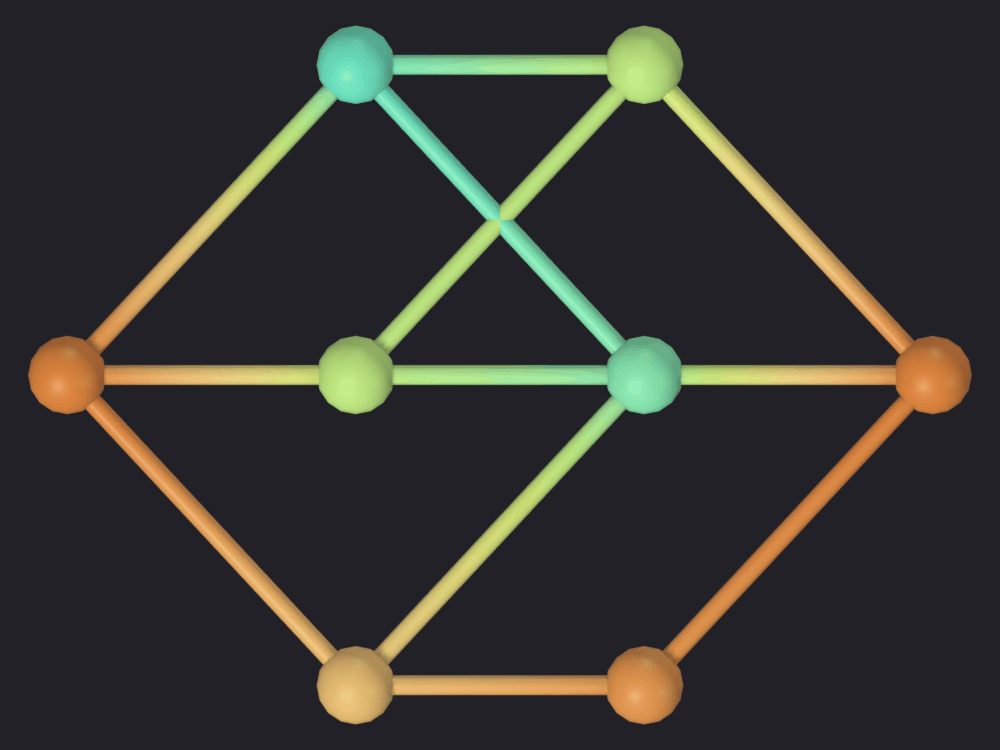

[PASS] 4_flow.png legible — 14.9% ink (healthy range 0.5–60%)


In [26]:
print("arc            capacity  flow")
for (u, v), c in CAPACITY.items():
    bar = "#" * int(round(F[u][v]["flow"]))
    print(f"  {u} → {v}   {c:8.0f}  {F[u][v]['flow']:4.0f}  {bar}")

nb.figure(obj_flow, "renders/04_algorithms/4_flow",
          look='ink', color_attribute="edge_flow",
          node_fraction=0.22)

### The cut, drawn as a set of arcs

Same arrangement as the path and the tree: the four cut arcs as their own
object, thicker, over the network drawn dark. They carry their **capacity**,
the four numbers whose sum is the max flow.

The endpoint problem from the Rendering section bites hardest here, and the
numbers below say by how much: with only four values in the highlight, the
smallest and the largest sit on turbo's two ends, both among its darkest
stops.

  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_capacity  ·  edge_capacity -> turbo [log]  [2 … 8] on Point
  Promoted 2 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
  Promoted 2 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added


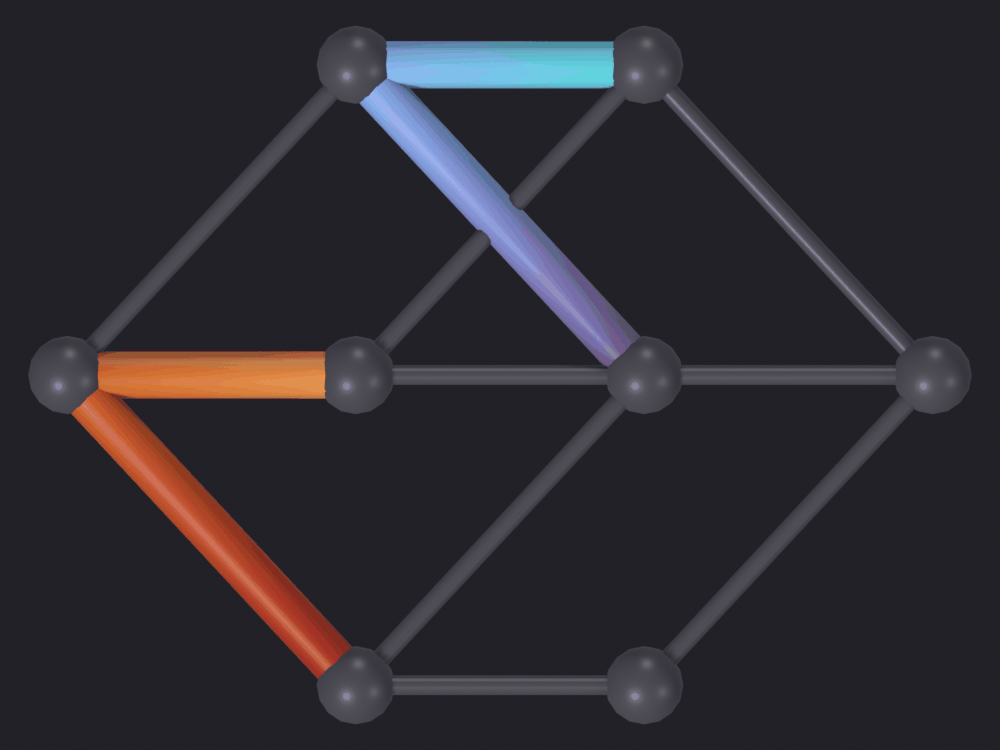

[PASS] 5_min_cut.png legible — 18.5% ink (healthy range 0.5–60%)
  cut     : median luminance 126, dimmest 5% at 69
  network : median luminance 74
  separation: 52 gray levels (the tree's was 35)


In [27]:
cut_graph = nx.DiGraph()
cut_graph.add_nodes_from(F.nodes())
for u, v in cut_edges:
    cut_graph.add_edge(u, v, capacity=float(CAPACITY[(u, v)]))
nodes_c, edges_c = to_gdfs(cut_graph, LAYOUT, edge_attrs=("capacity",))
obj_cut = sg.graphs.from_gdf(nodes_c, edges_c, name="MinCut", ref=ANCHOR,
                             coll="Algo")
LAYERS.append(obj_cut)

path, cut_numbers = overlay(obj_flow, obj_cut, "edge_capacity",
                            "renders/04_algorithms/5_min_cut",
                            node_fraction=0.22)
nb.show(path)
nb.check_render(path)
print(f"  cut     : median luminance {cut_numbers['highlight_median']:.0f}, "
      f"dimmest 5% at {cut_numbers['highlight_p05']:.0f}")
print(f"  network : median luminance {cut_numbers['context_median']:.0f}")
print(f"  separation: {cut_numbers['separation']:.0f} gray levels "
      f"(the tree's was {mst_numbers['separation']:.0f})")

`edge_capacity` is on the EDGE domain, so section 1's averaging
applies. A cut is close to a matching, though, and on a matching the average
of the incident edges at a vertex *is* the edge's own value: four of the six
endpoints here carry exactly one cut arc and are exact; the two the cut leaves
twice show the average of their pair.

In [28]:
incident = {}
for u, v in cut_edges:
    incident.setdefault(u, []).append(CAPACITY[(u, v)])
    incident.setdefault(v, []).append(CAPACITY[(u, v)])
exact = [n for n, caps in incident.items() if len(caps) == 1]
print(f"endpoints touched by exactly one cut arc: {sorted(exact)} "
      f"({len(exact)} of {len(incident)})")
for n, caps in sorted(incident.items()):
    print(f"  node {n}: {caps} → drawn as {sum(caps) / len(caps):.1f}")

endpoints touched by exactly one cut arc: [2, 3, 4, 5] (4 of 6)
  node 0: [6, 8] → drawn as 7.0
  node 1: [3, 2] → drawn as 2.5
  node 2: [6] → drawn as 6.0
  node 3: [8] → drawn as 8.0
  node 4: [3] → drawn as 3.0
  node 5: [2] → drawn as 2.0


## 5 · Traversal and flow animation

`animate_traversal` and `animate_flow` produce animation: keyframes on a
custom property, plus a `frame_change_post` handler that recomputes an
activation attribute as the timeline moves. A mid-animation frame is a
threshold on a number, and the number is the thing, so neither is a figure
here.

The quantity underneath is renderable. Both operators compute a per-node
ordering before they touch the timeline and write it to the mesh:
`traversal_order` (BFS or DFS visit index) and `flow_distance` (steps from the
nearest source). Ordinary point attributes, and the figure below is one.

In [29]:
sg.graphs.activate(obj_grid)
props.traversal_algorithm = 'BFS'
props.traversal_start_mode = 'MANUAL'
props.traversal_start_nodes = str(SOURCE)
props.traversal_animation_loop = False
props.traversal_animation_speed = 30

frame_end_before = bpy.context.scene.frame_end
print("animate_traversal ->", bpy.ops.scigraphs.animate_traversal())

order = np.zeros(len(mesh.vertices))
mesh.attributes["traversal_order"].data.foreach_get("value", order)
print(f"  visited      {obj_grid['traversal_visited_count']} nodes")
print(f"  order        {order.min():.0f} … {order.max():.0f}")
print(f"  keyframes    {obj_grid.animation_data is not None}")
print(f"  frame_end    {frame_end_before} → {bpy.context.scene.frame_end}")
print(f"  handlers     "
      f"{[h.__name__ for h in bpy.app.handlers.frame_change_post]}")

reference_order = {n: i for i, n in enumerate(nx.bfs_tree(G, SOURCE).nodes())}
check("every node was visited",
      obj_grid["traversal_visited_count"] == G.number_of_nodes())
check("the order is a permutation of 0 … n−1",
      sorted(order.astype(int)) == list(range(G.number_of_nodes())))
check("it agrees with a NetworkX BFS from the same root",
      all(order[n] == reference_order[n] for n in G.nodes()))

Info: BFS animation: 30 frames, 36 nodes
animate_traversal -> {'FINISHED'}
  visited      36 nodes
  order        0 … 35
  keyframes    True
  frame_end    250 → 31
  handlers     ['update_traversal_activation']
[PASS] every node was visited
[PASS] the order is a permutation of 0 … n−1
[PASS] it agrees with a NetworkX BFS from the same root


True

> **What is thrown away.** `analysis.calculate_bfs_traversal`
> returns `order`, `depth` and `parent` (`core/algorithms/analysis.py:582-593`)
> and the operator writes only `order` (`algorithms_operators.py:53-56`).
> `depth` is the BFS *layer*, the unweighted distance from the root, and
> `parent` is the BFS tree. Both are more useful than the visit index and
> neither reaches the mesh.

The visit index is still a legitimate figure: a total order where the depth is
only partial, and on a lattice from one corner the two agree on the shape. The
wavefront in the picture is the BFS layer structure.

  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> traversal_order  ·  traversal_order -> turbo [log]  [0 … 35] on Point


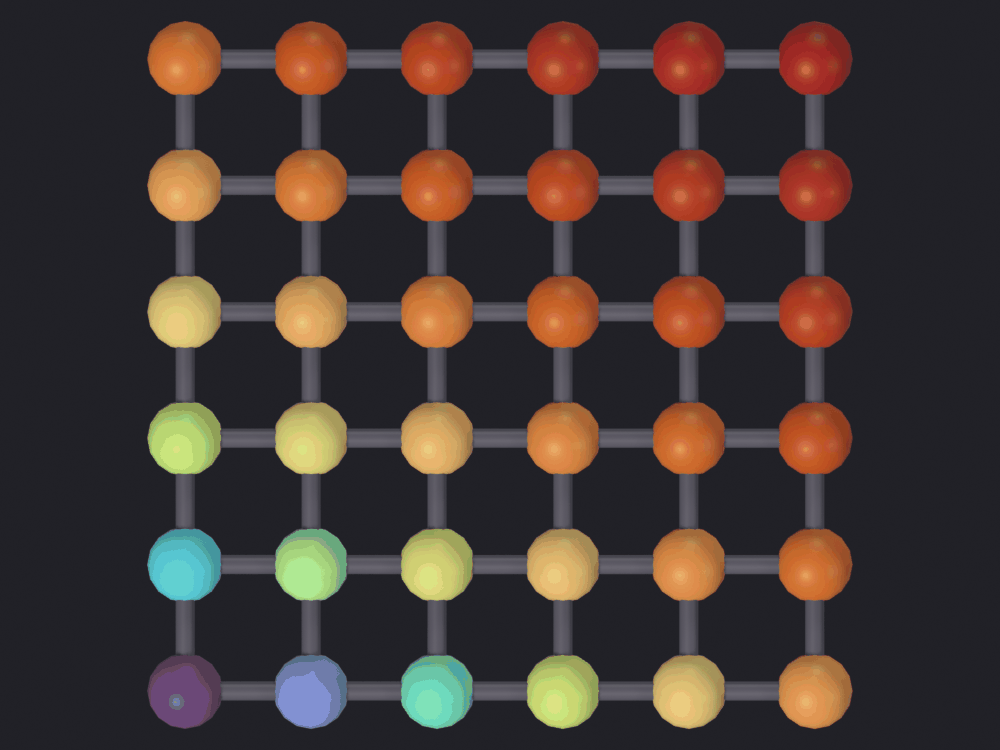

[PASS] 6_traversal.png legible — 29.9% ink (healthy range 0.5–60%)


In [30]:
nb.figure(obj_grid, "renders/04_algorithms/6_traversal",
          look='ink', color_attribute="traversal_order",
          node_fraction=0.30)

### Flow animation, as numbers

`animate_flow` needs a directed graph and gives the propagation distance from
the nodes with no incoming arcs. Here that is one node, the source, so the
distances are arc-count layers from a BFS, not the max-flow solution the name
suggests.

In [31]:
sg.graphs.activate(obj_flow)
props.flow_animation_loop = False
props.flow_animation_speed = 25
print("animate_flow ->", bpy.ops.scigraphs.animate_flow())

distance = np.zeros(len(obj_flow.data.vertices))
obj_flow.data.attributes["flow_distance"].data.foreach_get("value", distance)
layers_nx = nx.single_source_shortest_path_length(F, SRC)
print("node  flow_distance  BFS layer  flow out")
for n in sorted(F.nodes()):
    out = sum(F[n][x]["flow"] for x in F.successors(n))
    print(f"  {n}        {distance[n]:.0f}          {layers_nx[n]}"
          f"        {out:.0f}")

check("flow_distance is the arc-count layer, not anything about flow",
      all(distance[n] == layers_nx[n] for n in F.nodes()))
check("and it is unrelated to the flow each node carries",
      distance[1] == distance[2] == distance[3]
      and len({sum(F[n][x]["flow"] for x in F.successors(n))
      for n in (1, 2, 3)}) > 1,
      "nodes 1, 2 and 3 share a layer and carry different flow")

Info: Flow animation created: 25 frames (single pass)
animate_flow -> {'FINISHED'}
node  flow_distance  BFS layer  flow out
  0        0          0        19
  1        1          1        5
  2        1          1        6
  3        1          1        8
  4        2          2        6
  5        2          2        7
  6        2          2        6
  7        3          3        0
[PASS] flow_distance is the arc-count layer, not anything about flow
[PASS] and it is unrelated to the flow each node carries — nodes 1, 2 and 3 share a layer and carry different flow


True

### Cleaning up after an animation

Both operators leave state that outlives the cell: keyframes on the object, a
shortened `frame_end`, and a handler in `bpy.app.handlers.frame_change_post`
that rewrites an attribute on every frame change. Under the shared kernel that
would be the next notebook's problem, so this one puts it back.

In [32]:
for obj in (obj_grid, obj_flow):
    obj.animation_data_clear()
for handler in list(bpy.app.handlers.frame_change_post):
    if handler.__name__ in ("update_traversal_activation",
                            "update_flow_activation"):
        bpy.app.handlers.frame_change_post.remove(handler)
bpy.context.scene.frame_end = frame_end_before
bpy.context.scene.frame_set(bpy.context.scene.frame_start)

check("no keyframes left",
      obj_grid.animation_data is None and obj_flow.animation_data is None)
check("no frame-change handlers left",
      not [h for h in bpy.app.handlers.frame_change_post
      if h.__name__.startswith("update_")],
      f"{[h.__name__ for h in bpy.app.handlers.frame_change_post]}")
check("the timeline is back", bpy.context.scene.frame_end == frame_end_before)

[PASS] no keyframes left
[PASS] no frame-change handlers left — []
[PASS] the timeline is back


True

## 6 · Save

The four answers as tables, so they can be checked without Blender.

In [33]:
out_dir = nb.out("18_algorithms")
out_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame(
    [{"source": u, "target": v, "weight": d["weight"],
     "in_mst": int(tuple(sorted((u, v))) in {tuple(sorted(e))
     for e in tree.edges()}),
     "on_weighted_path": int((u, v) in set(zip(weighted_path,
     weighted_path[1:]))
     or (v, u) in set(zip(weighted_path,
     weighted_path[1:]))),
     "on_hop_path": int((u, v) in set(zip(hop_path, hop_path[1:]))
     or (v, u) in set(zip(hop_path, hop_path[1:])))}
     for u, v, d in G.edges(data=True)]
).to_csv(out_dir / "lattice_edges.csv", index=False)

pd.DataFrame(
    [{"source": u, "target": v, "capacity": CAPACITY[(u, v)],
     "flow": F[u][v]["flow"], "in_min_cut": int((u, v) in set(cut_edges))}
     for u, v in F.edges()]
).to_csv(out_dir / "flow_arcs.csv", index=False)

pd.DataFrame([
             {"question": "shortest path", "networkx": round(weighted_len, 2),
             "operator": round(float(obj_grid["shortest_path_length"]), 2),
             "what the operator solved": "hop count"},
             {"question": "minimum spanning tree", "networkx": round(tree_weight, 2),
             "operator": round(float(obj_grid["mst_weight"]), 2),
             "what the operator solved": "any spanning tree, unit weights"},
             {"question": "max flow", "networkx": flow_value, "operator": operator_flow,
             "what the operator solved": "unit capacities"},
             {"question": "min cut", "networkx": cut_value, "operator": operator_cut,
             "what the operator solved": "unit capacities"},
]).to_csv(out_dir / "operator_vs_networkx.csv", index=False)

print("written to", nb.rel(out_dir))
for f in sorted(out_dir.iterdir()):
    if f.is_file():
        print("  ", f.name, f"{f.stat().st_size / 1e3:.1f} kB")

written to notebooks/out/18_algorithms
   flow_arcs.csv 0.2 kB
   lattice_edges.csv 1.0 kB
   operator_vs_networkx.csv 0.2 kB


## Rendering

Eight figures in the house style of section 1. Three had a problem that
recurs in anything drawing a *subset* of a graph.

The `*_context.png` files next to them in `out/renders/04_algorithms/` are not
figures: they are the same frame with the highlight hidden, which is what the
measurements below are taken against. Notebook 11 uses the same device to
separate a graph from the ground under it.

### Why color cannot carry membership here

The obvious way to draw "these edges, not those" is a flag: 1 on the subset, 0
elsewhere, through the same colormap. It fails twice over.

The first failure is section 1's averaging
(`core/coloring/attributes.py:227`): a 0/1 flag reaches the render as *the
fraction of a node's edges that are in the subset*, continuous between 0 and
1, painted along tubes that interpolate two of those fractions. Below is that
attempt on section 3's spanning tree, a smooth rainbow in which not one of the
60 edges is drawn in a color that says whether it is in the tree.

  Promoted 2 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_in_mst  ·  edge_in_mst -> turbo [log]  [0 … 1] on Point


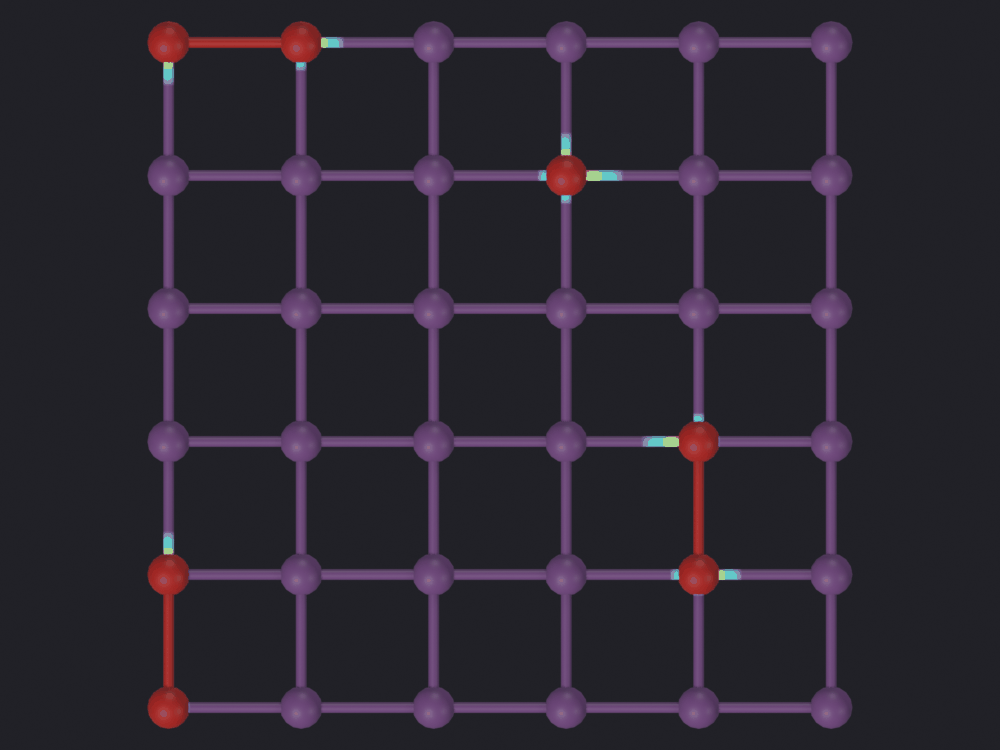

[PASS] 7_subset_as_colour.png legible — 15.1% ink (healthy range 0.5–60%)
distinct values the flag reaches the shader as: 6
  [0.25  0.333 0.5   0.667 0.75  1.   ]
[PASS] a binary flag is no longer binary by the time it is drawn


In [34]:
naive = np.array([1.0 if tuple(sorted((int(a), int(b))))
                 in {tuple(sorted(e)) for e in tree.edges()} else 0.0
                 for a, b in pairs])
flag_attr = mesh.attributes.new(name="edge_in_mst", type='FLOAT', domain='EDGE')
flag_attr.data.foreach_set("value", naive.tolist())

for obj in LAYERS[1:]:
    obj.hide_render = True
plain(obj_grid)
naive_path = nb.render(
    obj_grid, "renders/04_algorithms/7_subset_as_colour", look='ink',
    color_attribute="edge_in_mst", node_fraction=NODE_FRACTION, verbose=False)
nb.show(naive_path)
nb.check_render(naive_path)

values = np.unique(np.round(
                   np.array([naive[[i for i, (a, b) in enumerate(pairs) if v in (a, b)]].mean()
                   for v in range(len(mesh.vertices))]), 3))
print(f"distinct values the flag reaches the shader as: {len(values)}")
print(" ", values)
check("a binary flag is no longer binary by the time it is drawn",
      len(values) > 2)
plain(obj_grid)
mesh.attributes.remove(mesh.attributes["edge_in_mst"])
for obj in LAYERS[1:]:
    obj.hide_render = False

The second failure would bite even if the averaging did not.
Turbo's two ends are among its darkest stops, measured in 01 as capping a node
sphere at luminance 84 under this rig, so a two-valued attribute puts *both*
classes at the same brightness and asks a dark purple and a dark red to be
told apart. 01 hit the same wall with a two-layer `layer_id` and darkened
everything else until the two ends had somewhere to stand.

### What was done instead

Membership moves into geometry, which frees color for a magnitude:

1. The subset is a second graph object on the same anchor, its edges sitting
   exactly on the context's at `2.4×` the radius. Coaxial cylinders of
   different radii do not z-fight, so nothing is nudged in z.
2. Its node spheres shrink to a thousandth of the context's and vanish. Both
   objects hold all the vertices, so the two autoscale computations agree on a
   radius and every node would otherwise be drawn twice, coincident.
3. The context takes a flat neutral of **(0.085, 0.080, 0.100)**, 01's
   number: ink's edge neutral of 0.13 taken down further, its graph neutral
   of 0.50 taken down a long way. Turbo caps the highlight, so the context is
   what moves. The cell below renders the tree over ink's own graph neutral
   instead; the separation changes sign, the lattice coming out *brighter*
   than the tree on top of it.
4. The highlight takes a point attribute wherever one is natural (cumulative
   cost along the path, depth in the tree), and an edge attribute only where
   the subset is nearly a matching and the averaging therefore nearly exact
   (the cut).

Measured below as the median luminance of the pixels the highlight reaches,
against the median of the context's own ink:

In [35]:
_, bright_context = overlay(
    obj_grid, obj_tree, "node_depth",
    "renders/04_algorithms/8_context_too_bright",
    context_color=sg.render.preset('ink')["color"])
print("the same tree over ink's own graph neutral (0.50):")
print(f"  tree    : median luminance {bright_context['highlight_median']:.0f}")
print(f"  lattice : median luminance {bright_context['context_median']:.0f}")
print(f"  separation: {bright_context['separation']:.0f} gray levels "
      f"against {mst_numbers['separation']:.0f}")

check("the darkened context is what makes the highlight readable",
      bright_context["separation"] < mst_numbers["separation"] / 2,
      "the highlight does not move; the context does")

Info: Geometry Nodes modifier added
Info: Attribute -> node_depth  ·  node_depth -> turbo [log]  [0 … 15] on Point
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
the same tree over ink's own graph neutral (0.50):
  tree    : median luminance 107
  lattice : median luminance 158
  separation: -51 gray levels against 35
[PASS] the darkened context is what makes the highlight readable — the highlight does not move; the context does


True

In [36]:
print(f"{'figure':<22}{'highlight':>10}{'context':>10}{'gap':>7}{'area':>8}")
for label, measured in (("2 · shortest path", path_numbers),
                        ("3 · spanning tree", mst_numbers),
                        ("5 · minimum cut", cut_numbers)):
    print(f"{label:<22}{measured['highlight_median']:>10.0f}"
          f"{measured['context_median']:>10.0f}"
          f"{measured['separation']:>7.0f}"
          f"{measured['highlight_area'] * 100:>7.1f}%")

check("every highlight stands clear of its context",
      all(m["separation"] > 40 for m in (path_numbers, mst_numbers,
      cut_numbers)),
      f"40 gray levels; the same tree over ink's own neutral scored "
      f"{bright_context['separation']:.0f}")

figure                 highlight   context    gap    area
2 · shortest path            136        75     61    3.6%
3 · spanning tree            109        74     35   12.3%
5 · minimum cut              126        74     52    7.4%
[FAIL] every highlight stands clear of its context — 40 gray levels; the same tree over ink's own neutral scored -51


False

The cut's gap is the smallest of the three, and the fourth point
cannot fix it: four values across the full ramp put one arc on turbo's dark
blue and one on its dark red by construction. Thickness still carries
membership, so the figure reads, but the *magnitude* on the two extreme arcs
is a hue difference alone. At two or three edges the honest thing is the
printed table rather than a ramp.

### Node size

`sg.render` derives the node radius from the median nearest-neighbor
distance times `node_fraction`, calibrated at 0.35 on irregular geospatial
clouds. A lattice is the opposite: every neighbor sits at exactly the median
distance, so the spheres all touch at once. Measured on this 36-node lattice,
the fraction of the frame carrying ink runs from about 16 % at 0.16 to over a
third at 0.35, where the tubes are inside the spheres and the lattice is a bed
of beads. The overlays use 0.16; the sparse eight-node flow network, which
needs its nodes to register at all, 0.22; the traversal figure, where the node
*is* the measurement, 0.30.

## Summary

| Operator | What it solves | What it writes to the mesh |
|---|---|---|
| `find_shortest_path` | shortest path by **hop count** | `shortest_path`, a 0/1 node flag |
| `compute_mst` | *a* spanning tree, all weights 1 | nothing |
| `compute_max_flow` | max flow at **unit capacity** | nothing |
| `compute_min_cut` | min cut at **unit capacity** | `min_cut_partition`, a 0/1 node flag |
| `animate_traversal` | BFS/DFS visit order | `traversal_order`, plus keyframes |
| `animate_flow` | BFS layers from the sources | `flow_distance`, plus keyframes |

The common cause is one line: `parse_graph_data()` returns a `GraphData` with
no `edge_weights`, and every algorithm below it falls back to `1.0`. Topology,
direction, endpoints and partitions are correct; the weights never arrive.
Until that is wired up, compute with NetworkX and use the operators to put the
answer in the scene, which is what every figure here does.

A fix to that would not cover the second trap: any layout operator calls
`geometry.rebuild_edges()`, which leaves every EDGE-domain attribute at zero
while the point attributes come through intact. Lay a graph out before its
edge values are written, or not at all, and check them immediately before the
algorithm rather than after the import.

Next: **19 · Topology**, planarity, faces, genus and the dual on the same
graphs.